#***Final Model***


In [ ]:
Exp_2N = Netflix_Clustering_exp2.copy()

In [ ]:
Exp_2N.head()

,type,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,main_genre
0,TV Show,Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,8.0,International TV Shows
1,Movie,Mexico,2016-12-23,2016,TV-MA,93,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,12.0,Dramas
2,Movie,Singapore,2018-12-20,2011,R,78,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,12.0,Horror Movies
3,Movie,United States,2017-11-16,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0,Action & Adventure
4,Movie,United States,2020-01-01,2008,PG-13,123,Dramas,A brilliant group of students become card-coun...,2020.0,1.0,Dramas


Although features such as type and duration may help separate content into structurally distinct groups, they primarily capture obvious format-level differences such as Movies vs TV Shows. Since the goal of this project was to uncover deeper content-based and business-relevant segmentation, these features were removed to reduce dominance of known distinctions and allow clustering to focus on richer metadata such as genres, ratings, countries, and release patterns.

In [ ]:
#Now we need to drop columns like type, duration so that clustring would not lead to 2 clusters
Exp_2N.drop(['type'], axis=1, inplace=True)

In [ ]:
#Dropping not required columns
Exp_2N.drop(['description', 'main_genre'], axis = 1, inplace = True)

In [ ]:
Exp_2N = pd.get_dummies(Exp_2N, columns=['country','rating'], drop_first=True)

In [ ]:
Exp_2N.shape

(7777, 106)

In [ ]:
Exp_2N.columns.to_list()

['release_year',
 'listed_in',
 'year_added',
 'month_added',
 ' Anime Features',
 ' Children & Family Movies',
 ' Classic & Cult TV',
 ' Classic Movies',
 ' Comedies',
 ' Crime TV Shows',
 ' Cult Movies',
 ' Documentaries',
 ' Docuseries',
 ' Dramas',
 ' Faith & Spirituality',
 ' Horror Movies',
 ' Independent Movies',
 ' International Movies',
 ' International TV Shows',
 " Kids' TV",
 ' Korean TV Shows',
 ' LGBTQ Movies',
 ' Music & Musicals',
 ' Reality TV',
 ' Romantic Movies',
 ' Romantic TV Shows',
 ' Sci-Fi & Fantasy',
 ' Science & Nature TV',
 ' Spanish-Language TV Shows',
 ' Sports Movies',
 ' Stand-Up Comedy',
 ' Stand-Up Comedy & Talk Shows',
 ' TV Action & Adventure',
 ' TV Comedies',
 ' TV Dramas',
 ' TV Horror',
 ' TV Mysteries',
 ' TV Sci-Fi & Fantasy',
 ' TV Thrillers',
 ' Teen TV Shows',
 ' Thrillers',
 'Action & Adventure',
 'Anime Features',
 'Anime Series',
 'British TV Shows',
 'Children & Family Movies',
 'Classic & Cult TV',
 'Classic Movies',
 'Comedies',
 'Cri

In [ ]:
#Columns names are getting duplicated
Exp_2N.columns = Exp_2N.columns.str.strip()

In [ ]:
Exp_2N = Exp_2N.loc[:,~Exp_2N.columns.duplicated()]

In [ ]:
Exp_2N.shape

(7777, 75)

In [ ]:
Exp_2N.columns.to_list()

['release_year',
 'listed_in',
 'year_added',
 'month_added',
 'Anime Features',
 'Children & Family Movies',
 'Classic & Cult TV',
 'Classic Movies',
 'Comedies',
 'Crime TV Shows',
 'Cult Movies',
 'Documentaries',
 'Docuseries',
 'Dramas',
 'Faith & Spirituality',
 'Horror Movies',
 'Independent Movies',
 'International Movies',
 'International TV Shows',
 "Kids' TV",
 'Korean TV Shows',
 'LGBTQ Movies',
 'Music & Musicals',
 'Reality TV',
 'Romantic Movies',
 'Romantic TV Shows',
 'Sci-Fi & Fantasy',
 'Science & Nature TV',
 'Spanish-Language TV Shows',
 'Sports Movies',
 'Stand-Up Comedy',
 'Stand-Up Comedy & Talk Shows',
 'TV Action & Adventure',
 'TV Comedies',
 'TV Dramas',
 'TV Horror',
 'TV Mysteries',
 'TV Sci-Fi & Fantasy',
 'TV Thrillers',
 'Teen TV Shows',
 'Thrillers',
 'Action & Adventure',
 'Anime Series',
 'British TV Shows',
 'Movies',
 'TV Shows',
 'country_Brazil',
 'country_Canada',
 'country_Egypt',
 'country_France',
 'country_India',
 'country_Japan',
 'country

In [ ]:
Exp_2N.drop('listed_in', axis=1, inplace=True)

In [ ]:
Exp_2N.shape

(7777, 74)

In [ ]:
Exp_2N.columns

Index(['release_year', 'year_added', 'month_added', 'Anime Features',
       'Children & Family Movies', 'Classic & Cult TV', 'Classic Movies',
       'Comedies', 'Crime TV Shows', 'Cult Movies', 'Documentaries',
       'Docuseries', 'Dramas', 'Faith & Spirituality', 'Horror Movies',
       'Independent Movies', 'International Movies', 'International TV Shows',
       'Kids' TV', 'Korean TV Shows', 'LGBTQ Movies', 'Music & Musicals',
       'Reality TV', 'Romantic Movies', 'Romantic TV Shows',
       'Sci-Fi & Fantasy', 'Science & Nature TV', 'Spanish-Language TV Shows',
       'Sports Movies', 'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows',
       'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror',
       'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Thrillers', 'Teen TV Shows',
       'Thrillers', 'Action & Adventure', 'Anime Series', 'British TV Shows',
       'Movies', 'TV Shows', 'country_Brazil', 'country_Canada',
       'country_Egypt', 'country_France', 'country_I

In [ ]:
Exp_2N.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7777 entries, 0 to 7786
Data columns (total 74 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   release_year                  7777 non-null   int64  
 1   year_added                    7777 non-null   float64
 2   month_added                   7777 non-null   float64
 3   Anime Features                7777 non-null   int64  
 4   Children & Family Movies      7777 non-null   int64  
 5   Classic & Cult TV             7777 non-null   int64  
 6   Classic Movies                7777 non-null   int64  
 7   Comedies                      7777 non-null   int64  
 8   Crime TV Shows                7777 non-null   int64  
 9   Cult Movies                   7777 non-null   int64  
 10  Documentaries                 7777 non-null   int64  
 11  Docuseries                    7777 non-null   int64  
 12  Dramas                        7777 non-null   int64  
 13  Faith & 

**“Although scaling is generally recommended for numerical features, in this case it degraded clustering performance due to the dominance of high-dimensional NLP features. Therefore, I retained the original feature scale to preserve meaningful distance relationships.”**

In [ ]:
# #Applying scaling on numeric columns
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

# num_cols = ['release_year', 'year_added', 'month_added']

# scaler = StandardScaler()
# Exp_2N[num_cols] = scaler.fit_transform(Exp_2N[num_cols])


In [ ]:
Exp_2N.dtypes.value_counts()

,count
int64,43
bool,29
float64,2


In [ ]:
non_numeric_cols = Exp_2N.select_dtypes(include=['object']).columns
print("Non-numeric columns:", list(non_numeric_cols))

Non-numeric columns: []


In [ ]:
Exp_2N = Exp_2N.apply(pd.to_numeric)

In [ ]:
Exp_2N = Exp_2N.astype(int)

In [ ]:
Exp_2N.head()

,release_year,year_added,month_added,Anime Features,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,2020,2020,8,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,2016,2016,12,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,2011,2018,12,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,2009,2017,11,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,2008,2020,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
Exp_2N.shape

(7777, 74)

In [ ]:
Exp_2N.dtypes.value_counts()

,count
int64,74


In [ ]:
from scipy.sparse import csr_matrix, hstack
#convert to sparse matrix
structured_matrix_2 = csr_matrix(Exp_2N.values)
print("Structured matrix shape:", structured_matrix_2.shape)

Structured matrix shape: (7777, 74)


In [ ]:
# Step 6: Combine with NLP matrices
final_feature_matrix_2 = hstack([
    structured_matrix_2,
    description_matrix,
    title_matrix,
    cast_matrix,
    director_matrix
])

print("Final combined feature matrix shape:", final_feature_matrix_2.shape)

Final combined feature matrix shape: (7777, 2524)


##***Dimensionality Reduction***

#####**We are going to use TruncatedSVD for Dimensionality Reduction as we have matrix of features**

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd_2 = TruncatedSVD(n_components=100, random_state=42)
X_svd_100_2= svd_2.fit_transform(final_feature_matrix_2)

print("SVD matrix shape:", X_svd_100_2.shape)

SVD matrix shape: (7777, 100)


In [ ]:
print("Explained Variance:", svd_2.explained_variance_ratio_.sum())

Explained Variance: 0.9512498336009385


##### Do you think that dimensionality reduction is needed? Explain Why?

After applying encoding the shape of the dataset is - 7777 X 108. It will be difficult for clustering algorithms to handle these many features so we have to apply dimensionality reduction.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

##***ML Model Implementation***

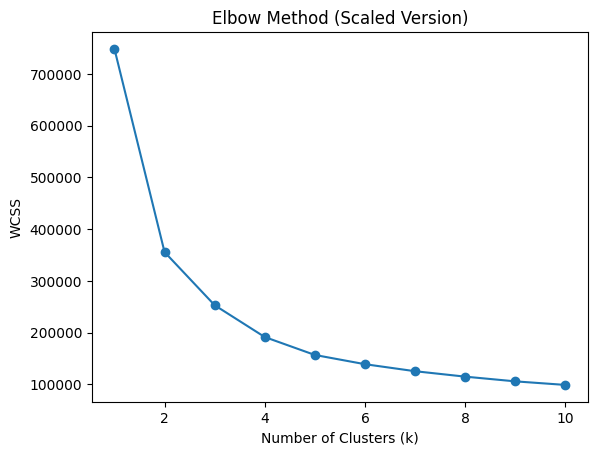

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_svd_100_2)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method (Scaled Version)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

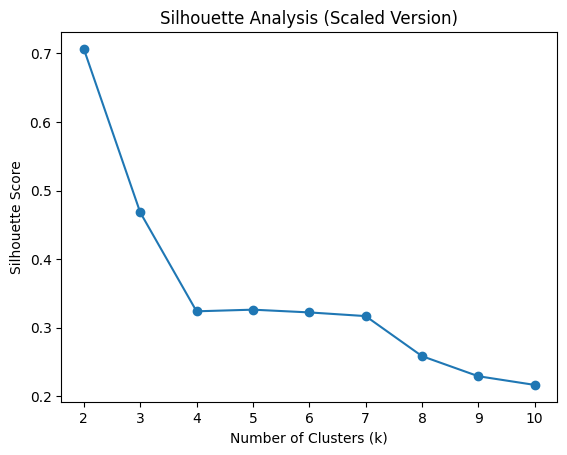

In [ ]:
from sklearn.metrics import silhouette_score

scores1 = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_svd_100_2)
    score = silhouette_score(X_svd_100_2, labels)
    scores1.append(score)

plt.plot(range(2, 11), scores1, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis (Scaled Version)")
plt.show()

In [ ]:
print(scores1)

[np.float64(0.706501048535263), np.float64(0.46824002972714623), np.float64(0.3239124609557251), np.float64(0.3263024294132102), np.float64(0.3223010403443552), np.float64(0.31693327536363086), np.float64(0.25853450639972), np.float64(0.22922556069412836), np.float64(0.2165737523045899)]


In [ ]:
from sklearn.cluster import KMeans

# k = 2
kmeans_2_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2_2 = kmeans_2_2.fit_predict(X_svd_100_2)

# k = 3
kmeans_3_2 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3_2 = kmeans_3_2.fit_predict(X_svd_100_2)

# k = 4
kmeans_4_2 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4_2 = kmeans_4_2.fit_predict(X_svd_100_2)

In [ ]:
Exp_2N['Cluster_k2'] = labels_2_2
Exp_2N['Cluster_k3'] = labels_3_2
Exp_2N['Cluster_k4'] = labels_4_2

In [ ]:
print("K=2:\n", Netflix_Clustering['Cluster_k2'].value_counts())
print("\nK=3:\n", Netflix_Clustering['Cluster_k3'].value_counts())
print("\nK=4:\n", Netflix_Clustering['Cluster_k4'].value_counts())

K=2:
 Cluster_k2
1    5067
0    2710
Name: count, dtype: int64

K=3:
 Cluster_k3
0    3603
1    2599
2    1575
Name: count, dtype: int64

K=4:
 Cluster_k4
2    3192
1    2533
0    1087
3     965
Name: count, dtype: int64


In [ ]:
Exp_2N_features = Exp_2N.drop(['Cluster_k2', 'Cluster_k3', 'Cluster_k4'], axis=1, errors = "ignore")

In [ ]:
cluster_insights_n = Exp_2N_features.groupby(Exp_2N["Cluster_k3"]).mean().T

In [ ]:
cluster_insights_n[0].sort_values(ascending=False).head(15)

,0
year_added,2018.570743
release_year,2005.590727
month_added,6.483613
International Movies,0.341327
country_United States,0.338129
country_Other,0.269384
rating_TV-14,0.265388
country_India,0.201439
Action & Adventure,0.172662
rating_R,0.161471


In [ ]:
cluster_insights_n[1].sort_values(ascending=False).head(15)

,1
year_added,2018.486512
release_year,2017.115722
month_added,6.804310
rating_TV-MA,0.420750
country_United States,0.321788
International Movies,0.286832
country_Other,0.260335
rating_TV-14,0.240543
rating_TV-PG,0.102634
country_India,0.099282


In [ ]:
cluster_insights_n[2].sort_values(ascending=False).head(15)

,2
year_added,2018.287356
release_year,1977.609195
month_added,7.731801
country_United States,0.421456
International Movies,0.379310
rating_TV-14,0.340996
Dramas,0.283525
country_Other,0.260536
Action & Adventure,0.237548
country_India,0.187739


Cluster Insights for K=4

In [ ]:
cluster_insights_n_2 = Exp_2N_features.groupby(Exp_2N["Cluster_k4"]).mean().T

In [ ]:
cluster_insights_n_2[0].sort_values(ascending=False).head(15)

,0
year_added,2018.350902
release_year,2016.894586
month_added,9.683758
rating_TV-MA,0.390719
country_United States,0.320252
International Movies,0.282727
country_Other,0.268977
rating_TV-14,0.246921
rating_TV-PG,0.111429
country_India,0.107706


In [ ]:
cluster_insights_n_2[1].sort_values(ascending=False).head(15)

,1
year_added,2018.331967
release_year,1976.676230
month_added,7.737705
country_United States,0.413934
International Movies,0.393443
rating_TV-14,0.356557
Dramas,0.295082
country_Other,0.262295
Action & Adventure,0.250000
country_India,0.200820


In [ ]:
cluster_insights_n_2[2].sort_values(ascending=False).head(15)

,2
year_added,2018.643285
release_year,2016.874003
month_added,3.444149
rating_TV-MA,0.434840
country_United States,0.322473
International Movies,0.291888
country_Other,0.252992
rating_TV-14,0.236037
Independent Movies,0.101729
country_India,0.095412


In [ ]:
cluster_insights_n_2[3].sort_values(ascending=False).head(15)

,3
year_added,2018.576402
release_year,2004.192456
month_added,6.483559
International Movies,0.350097
country_United States,0.348162
country_Other,0.263056
rating_TV-14,0.260155
country_India,0.204062
Action & Adventure,0.177950
rating_R,0.170213


In [ ]:
cluster_summary = Exp_2N.groupby('Cluster_k4').mean()

In [ ]:
cluster_summary.T.sort_values(by=0, ascending=False).head(10)

Cluster_k4,0,1,2,3
year_added,2018.350902,2018.331967,2018.643285,2018.576402
release_year,2016.894586,1976.676230,2016.874003,2004.192456
month_added,9.683758,7.737705,3.444149,6.483559
Cluster_k3,0.965339,2.000000,0.962434,0.032882
rating_TV-MA,0.390719,0.127049,0.434840,0.152805
country_United States,0.320252,0.413934,0.322473,0.348162
International Movies,0.282727,0.393443,0.291888,0.350097
country_Other,0.268977,0.262295,0.252992,0.263056
rating_TV-14,0.246921,0.356557,0.236037,0.260155
rating_TV-PG,0.111429,0.155738,0.094415,0.089942


In [ ]:
import pickle
with open('kmeans_model.pkl', 'wb') as f:
  pickle.dump(kmeans_4_2, f)

In [ ]:
with open('svd_model.pkl', 'wb') as f:
    pickle.dump(svd_2, f)

In [ ]:
pickle.dump(description_vectorizer, open('desc_vectorizer.pkl', 'wb'))
pickle.dump(title_vectorizer, open('title_vectorizer.pkl', 'wb'))
pickle.dump(cast_vectorizer, open('cast_vectorizer.pkl', 'wb'))
pickle.dump(director_vectorizer, open('director_vectorizer.pkl', 'wb'))

#***🔍 Cluster Insights***

The clustering model segmented Netflix content into four distinct groups based on a combination of metadata features such as release year, genre composition, content rating, and country distribution. Since format-based features like type and duration were intentionally removed, the clusters are driven primarily by content characteristics and audience targeting, rather than simple distinctions like Movies vs TV Shows. This allows for a more meaningful segmentation aligned with how users consume content on streaming platforms.

The first cluster, **“Modern Streaming-Era Content (Series + Mature Films)”**, represents recent content (post-2015) with a strong presence of TV-MA rated titles, including both series and films. It reflects the rise of binge-worthy, globally distributed content tailored for mature audiences. In contrast, **“Classic & Legacy Cinema”** captures much older titles (around 1970s–1980s), dominated by traditional genres like drama and action, representing archival and nostalgia-driven content that differs significantly in style and storytelling from modern productions.

The third cluster, **“Mature & Independent Adult Content (Movies + Series)”**, consists of modern content with a strong emphasis on darker themes, independent productions, and high maturity ratings. Unlike the first cluster, it is less dominated by mainstream streaming patterns and more aligned with niche, serious storytelling. Finally, **“Mainstream Global Feature Films”** represents broadly appealing content from the early 2000s, characterized by a balanced mix of genres (action, drama, romance, comedy) and diverse geographic origins. This cluster reflects commercially viable, widely consumable content that forms the core of global entertainment libraries.